In [1]:
import matplotlib.pyplot as plt
import PcmPy as pcm
from Plot import save_figure_incremental, make_axes_square
import os
import globals as gl
import pickle
import numpy as np
from Pcm import make_planning_models, make_execution_models, find_model

plt.style.use('default')

Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/


Figure saved to: /cifs/diedrichsen/data/SensoriMotorPrediction/figures/planning_models.svg


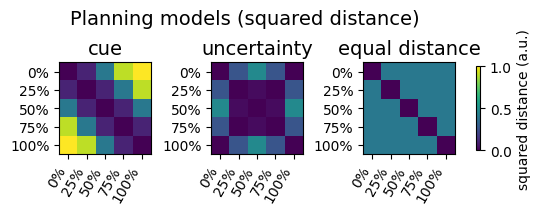

In [2]:
experiment = 'smp2'

M = make_planning_models()

D, G, name = [], [], []
for m in M:
    if isinstance(m, pcm.FixedModel) & (m.name != 'null') & (m.name != 'planning force'):
        D.append(pcm.G_to_dist(m.G / np.trace(m.G)))
        G.append(m.G)
        name.append(m.name)

fig, axs = plt.subplots(1, len(D), figsize=(5, 2), )

for i, (g, d, n) in enumerate(zip(G, D, name)):
    cax = axs[i].imshow(d, vmin=0, vmax=1, )
    axs[i].set_title(n, fontsize=14, )
    axs[i].set_xticks(np.arange(5))
    axs[i].set_xticklabels(list(gl.regressor_mapping.keys())[:5], rotation=60, ha='right')
    axs[i].set_yticks(np.arange(5))
    axs[i].set_yticklabels(list(gl.regressor_mapping.keys())[:5], rotation=0, ha='right')

fig.suptitle('Planning models (squared distance)', fontsize=14,)
fig.tight_layout()

# Add a single colorbar for the entire figure
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=0.01)
cbar.set_label("squared distance (a.u.)")

save_figure_incremental(fig, 'planning_models')

plt.show()



Figure saved to: /cifs/diedrichsen/data/SensoriMotorPrediction/figures/planning_models_mds.svg


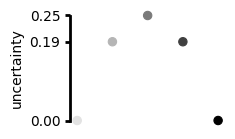

In [3]:
experiment = 'smp2'

M = make_planning_models(centering=True)

D, G, name = [], [], []
for m in M:
    if isinstance(m, pcm.FixedModel) & ((m.name == 'cue') | (m.name == 'uncertainty')):
        D.append(pcm.G_to_dist(m.G))
        G.append(m.G)
        name.append(m.name)

mds = []

for i, g in enumerate(G):
    mds_tmp, _ = pcm.classical_mds(g)
    mds.append(mds_tmp[:, 0])

mds = np.array(mds)  * -1

fig, axs = plt.subplots(figsize=(2, 1.5))
axs.scatter(mds[0], mds[1], c=list(gl.colour_mapping.values())[:5], lw=.8)
axs.set_xticks([])
axs.set_yticks(np.unique(np.round(mds[1], decimals=3)))
# axs.set_xticklabels(list(gl.regressor_mapping.keys())[:5][::-1], rotation=45, ha='right')
axs.set_yticklabels([f'{tick:.2f}' for tick in [0, 0.1875, .25]], ha='right', )

# Remove upper and left spines
axs.spines[['top', 'right', 'bottom']].set_visible(False)

# Bind x spines to -2 and 2 and y spines to 0 and 0.25
axs.spines['bottom'].set_bounds(-1, 1)
axs.spines['left'].set_bounds(mds[1].min(), mds[1].max())

# Set remaining spines' linewidth to 2
axs.spines['bottom'].set_linewidth(2)
axs.spines['left'].set_linewidth(2)

# Set tick width to 2
axs.tick_params(width=2)

axs.set_ylabel('uncertainty')

save_figure_incremental(fig, 'planning_models_mds')

plt.show()

Figure saved to: /cifs/diedrichsen/data/SensoriMotorPrediction/figures/execution_models.svg


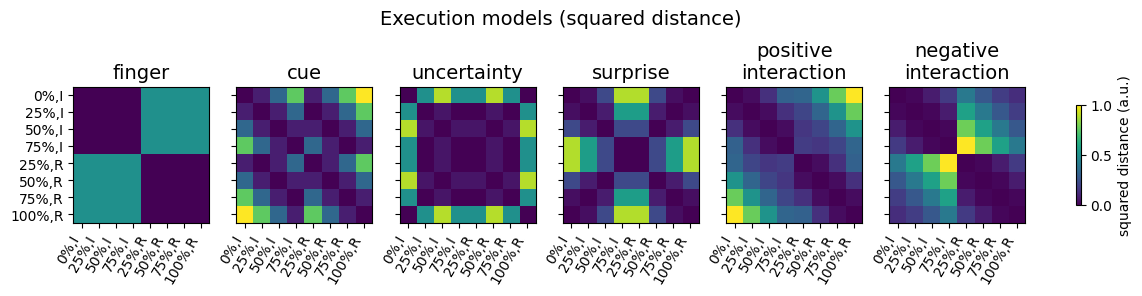

In [51]:
experiment = 'smp2'

M = make_execution_models(centering=True)

D,  name = [], []
for m in M:
    if isinstance(m, pcm.FixedModel) & (m.name != 'null') & (m.name != 'planning force'):
        D.append(pcm.G_to_dist(m.G / np.trace(m.G)))
        name.append(m.name)
    if isinstance(m, pcm.FeatureModel):
        Ac_pos = (m.Ac * np.array([1, 1, 1, 1, 0, 0])[:, None, None]).sum(axis=0)
        Gx_pos = Ac_pos @ Ac_pos.T
        Ac_neg = (m.Ac * np.array([1, 1, -2, 0, 0, 0])[:, None, None]).sum(axis=0)
        Gx_neg = Ac_neg @ Ac_neg.T
        D.append(pcm.G_to_dist(Gx_pos / np.trace(Gx_pos)))
        D.append(pcm.G_to_dist(Gx_neg / np.trace(Gx_neg)))
        name.append('positive\ninteraction')
        name.append('negative\ninteraction')

# Set vmin and vmax values for all images
vmin, vmax = 0, 1

fig, axs = plt.subplots(1, len(D), figsize=(13, 3), sharey=True, sharex=True,)

for i, ( d, n) in enumerate(zip(D, name)):
    im = axs[i].imshow(d, vmin=vmin, vmax=vmax)
    axs[i].set_title(n, fontsize=14)

    axs[i].set_xticks(np.arange(8))
    axs[i].set_xticklabels(list(gl.regressor_mapping.keys())[5:13], rotation=60, ha='right')
    axs[i].set_yticks(np.arange(8))
    axs[i].set_yticklabels(list(gl.regressor_mapping.keys())[5:13], ha='right')

# Add a single colorbar for the entire figure
cbar = fig.colorbar(im, ax=axs, orientation='vertical', fraction=0.005)
cbar.set_label("squared distance (a.u.)")

fig.suptitle('Execution models (squared distance)', fontsize=14)

save_figure_incremental(fig, 'execution_models')

plt.show()

Figure saved to: /cifs/diedrichsen/data/SensoriMotorPrediction/figures/execution_models_mds.svg


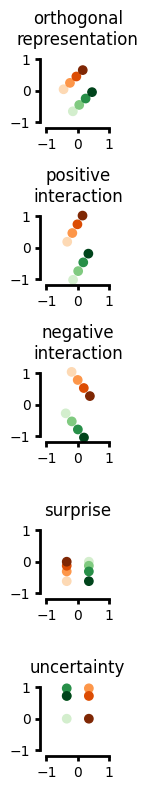

In [57]:
experiment = 'smp2'

M = make_execution_models(centering=False, normalize=False)

M, _ = find_model(M, 'feature')

Ac_ind = (M.Ac * np.array([1, 0, 0, 1, 0, 0])[:, None, None]).sum(axis=0)
G_ind = Ac_ind @ Ac_ind.T

Ac_crt = (M.Ac * np.array([1, 0, 0, 0, 2, 0])[:, None, None]).sum(axis=0)
G_crt = Ac_crt @ Ac_crt.T

Ac_spr = (M.Ac * np.array([1, 0, 0, 0, 0, 1])[:, None, None]).sum(axis=0)
G_spr= Ac_spr @ Ac_spr.T

Ac_pos = (M.Ac * np.array([1, 1, 1, .5, 0, 0])[:, None, None]).sum(axis=0)
Gx_pos = Ac_pos @ Ac_pos.T

Ac_neg = (M.Ac * np.array([1, 1, -2, .5, 0, 0])[:, None, None]).sum(axis=0)
Gx_neg = Ac_neg @ Ac_neg.T

mds_spr = pcm.classical_mds(G_spr)[0].T
mds_crt = pcm.classical_mds(G_crt)[0].T
mds_ind = pcm.classical_mds(G_ind)[0].T
mdsx_pos = pcm.classical_mds(Gx_pos)[0].T
mdsx_neg = pcm.classical_mds(Gx_neg)[0].T

fig, axs = plt.subplots(5, figsize=(6, 8), )
axs[4].scatter(mds_crt[1], mds_crt[0], c=list(gl.colour_mapping.values())[5:13],)
axs[3].scatter(mds_spr[1], mds_spr[0], c=list(gl.colour_mapping.values())[5:13],)
axs[1].scatter(mdsx_pos[1], mdsx_pos[0], c=list(gl.colour_mapping.values())[5:13],)
axs[2].scatter(mdsx_neg[1], mdsx_neg[0], c=list(gl.colour_mapping.values())[5:13],)
axs[0].scatter(mds_ind[1], mds_ind[0], c=list(gl.colour_mapping.values())[5:13],)

for ax in axs:
    ax.set_aspect('equal')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Ensure only the left spine is visible and set its bounds and style
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_bounds(-1, 1)
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_bounds(-1, 1)
    ax.spines['bottom'].set_linewidth(2)

    # Set tick parameters
    ax.tick_params(width=2)
    ax.set_xlim((-1.2, 1.2))
    ax.set_ylim(ax.get_xlim())

axs[0].set_title('orthogonal\nrepresentation')
axs[1].set_title('positive\ninteraction') # linear order of cues mantained
axs[2].set_title('negative\ninteraction') # linear order of cues reversed
axs[3].set_title('surprise') # linear order of cues reversed
axs[4].set_title('uncertainty')

fig.tight_layout()

save_figure_incremental(fig, 'execution_models_mds')

plt.show()

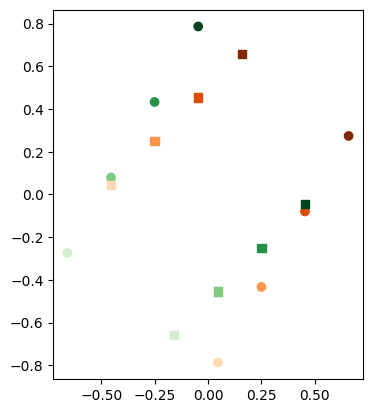

In [31]:
experiment = 'smp2'

M = make_execution_models(centering=False)

M, _ = find_model(M, 'feature')

Ac_ind = (M.Ac * np.array([1, 0, 0, 1, 0, 0])[:, None, None]).sum(axis=0)
G_ind = Ac_ind @ Ac_ind.T

Ac_spr = (M.Ac * np.array([2, 0, 0, 0, 0, 1])[:, None, None]).sum(axis=0)
G_spr= Ac_spr @ Ac_spr.T

Ac_pos = (M.Ac * np.array([1, 1, -1, 1, 0, 0])[:, None, None]).sum(axis=0)
Gx_pos = Ac_pos @ Ac_pos.T

Ac_neg = (M.Ac * np.array([1, 1, -2, 0, 0, 0])[:, None, None]).sum(axis=0)
Gx_neg = Ac_neg @ Ac_neg.T

mds_spr = pcm.classical_mds(G_spr)[0].T
mds_ind = pcm.classical_mds(G_ind)[0].T
mdsx_pos = pcm.classical_mds(Gx_pos)[0].T
mdsx_neg = pcm.classical_mds(Gx_neg)[0].T

plt.scatter(mdsx_pos[1], mdsx_pos[0], c=list(gl.colour_mapping.values())[5:13],)
plt.scatter(mds_ind[1], mds_ind[0], c=list(gl.colour_mapping.values())[5:13], marker='s')
plt.gca().set_aspect('equal')